## Import Packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Feature Dataset & P-value Rank
* Results of ML3-1 and ML3-2

In [3]:
FeatureData = pd.read_csv(
    "../ML3/data/FeatureData.csv",
    sep=",",
    header=None,
)
FeatureData.shape

(270, 360)

In [4]:
P_value_Rank = pd.read_csv(
    "../ML3/data/P_value_Rank.csv",
    sep=",",
    header=None,
)
P_value_Rank

,0,1
0,198.0,4.762393e-81
1,110.0,5.270311e-77
2,170.0,4.615377e-76
3,133.0,5.747675e-74
4,134.0,7.585991e-74
...,...,...
265,85.0,8.999631e-01
266,95.0,9.358453e-01
267,255.0,9.450087e-01
268,217.0,9.695416e-01


## Select Target Features for Demensionality Reduction Based on P-value

In [5]:
# Select features from StartRank to StartRank+Num
StartRank = 1
Num = 30

SelectedFeatues = np.zeros((Num, FeatureData.shape[1]))

s = 0
for i in range(StartRank, StartRank + Num):
    index = int(P_value_Rank.iloc[i - 1, 0])
    SelectedFeatues[s, :] = FeatureData.iloc[index, :].values
    s += 1

FeatureSelected = pd.DataFrame(SelectedFeatues).T
FeatureSelected

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.481424,1.268380,12.777754,0.654730,0.428672,-2.7173,1.620323,0.167877,0.028183,1.265919,...,0.095414,1.449463,1.583225,0.731190,0.534615,1.970872,2.142956,1.757904,-1.389085,1.548169
1,1.478799,1.428695,13.280290,0.649638,0.421593,-2.7250,1.597625,0.167090,0.027919,1.299383,...,0.095599,1.482249,1.645840,0.732929,0.537179,1.911625,2.389259,1.902583,-1.373162,1.664589
2,1.482299,1.430385,12.905222,0.641463,0.411441,-2.7224,1.625148,0.172784,0.029854,1.281556,...,0.095412,1.493831,1.640594,0.731354,0.534865,1.968504,2.347563,1.839163,-1.401283,1.613160
3,1.477326,1.428752,13.079692,0.638104,0.406741,-2.7520,1.575759,0.172377,0.029714,1.303882,...,0.095632,1.438521,1.586325,0.735156,0.540450,1.875148,2.353907,1.798335,-1.398744,1.571165
4,1.478828,1.435017,12.862634,0.627408,0.393194,-2.7517,1.564056,0.171432,0.029389,1.295184,...,0.095620,1.441050,1.596723,0.737189,0.543447,1.854403,2.308322,1.769507,-1.409967,1.545715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1.489518,1.433793,12.231166,0.671847,0.450741,-2.8459,1.578616,0.180131,0.032447,1.271762,...,0.095817,1.335111,1.488136,0.739743,0.547219,1.895502,2.205750,1.679486,-1.447667,1.474148
356,1.485393,1.478560,11.902660,0.661014,0.436692,-2.8570,1.540658,0.184310,0.033970,1.269566,...,0.095778,1.328678,1.485636,0.741043,0.549134,1.839912,2.190754,1.649162,-1.452517,1.458351
357,1.486447,1.478878,11.811784,0.681616,0.464223,-2.8318,1.588620,0.185856,0.034543,1.275704,...,0.095855,1.349357,1.503535,0.738831,0.545871,1.908137,2.095340,1.603096,-1.448879,1.406252
358,1.489181,1.470033,12.339840,0.672230,0.451389,-2.8524,1.522793,0.171050,0.029258,1.273485,...,0.095829,1.407482,1.561305,0.737491,0.543893,1.816432,2.269790,1.724622,-1.438261,1.510040


## Data Standardization / Normalization(Min-Max scaling)


Packages for Principal Component Analysis (PCA)

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#### Standardization of features

In [7]:
FeatureSelected_std = StandardScaler().fit_transform(FeatureSelected)
FeatureSelected_std = pd.DataFrame(FeatureSelected_std)
FeatureSelected_std

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-0.776847,-3.420112,0.469637,-0.171224,-0.180105,0.773818,0.726666,-1.405927,-1.381434,-1.841564,...,-0.841828,0.955834,0.630511,-1.676357,-1.676805,1.150744,-1.036622,0.291819,1.077970,0.437809
1,-1.526489,-0.292716,1.311470,-0.381671,-0.402063,0.708676,0.352155,-1.512154,-1.480919,1.233430,...,-0.184274,1.588483,1.738461,-1.049556,-1.048898,0.324519,1.667064,2.137192,1.584065,2.159386
2,-0.526880,-0.259748,0.683167,-0.719494,-0.720387,0.730672,0.806293,-0.743554,-0.750557,-0.404665,...,-0.850615,1.811973,1.645642,-1.617501,-1.615593,1.117717,1.209363,1.328276,0.690309,1.398872
3,-1.947166,-0.291613,0.975434,-0.858271,-0.867777,0.480255,-0.008646,-0.798420,-0.803505,1.646881,...,-0.066091,0.744706,0.685365,-0.246405,-0.248233,-0.184173,1.279003,0.807513,0.770988,0.777862
4,-1.518389,-0.169397,0.611825,-1.300261,-1.292566,0.482793,-0.201750,-0.926091,-0.926229,0.847654,...,-0.108186,0.793503,0.869357,0.486315,0.485603,-0.473467,0.778615,0.439825,0.414305,0.401520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1.534911,-0.193261,-0.445990,0.536100,0.511937,-0.314142,0.038488,0.248310,0.228124,-1.304660,...,0.593625,-1.250702,-1.052031,1.407219,1.409167,0.099680,-0.347324,-0.708382,-0.783891,-0.656796
356,0.356688,0.680043,-0.996295,0.088451,0.071388,-0.408049,-0.587832,0.812514,0.803010,-1.506446,...,0.453190,-1.374831,-1.096270,1.875884,1.878075,-0.675541,-0.511946,-1.095166,-0.938045,-0.890393
357,0.657705,0.686250,-1.148526,0.939807,0.934670,-0.194856,0.203567,1.021315,1.019108,-0.942348,...,0.726120,-0.975816,-0.779554,1.078615,1.079174,0.275882,-1.559304,-1.682735,-0.822419,-1.660818
358,1.438797,0.513686,-0.263944,0.551953,0.532235,-0.369132,-0.882609,-0.977644,-0.975592,-1.146249,...,0.635875,0.145764,0.242660,0.595402,0.594936,-1.002981,0.355644,-0.132681,-0.484962,-0.126028


#### Normalization of features (Min-Max)

In [8]:
FeatureSelected_norm = MinMaxScaler().fit_transform(FeatureSelected)
FeatureSelected_norm = pd.DataFrame(FeatureSelected_norm)
FeatureSelected_norm

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.358431,0.203143,0.399231,0.439293,0.415872,0.932979,0.458883,0.267465,0.246855,0.020500,...,0.350849,0.705157,0.625540,0.163757,0.161590,0.510356,0.315311,0.358045,0.303900,0.381899
1,0.234674,0.693211,0.560965,0.400644,0.375409,0.924966,0.393103,0.246277,0.226750,0.754360,...,0.477287,0.805861,0.793154,0.280109,0.278150,0.378870,0.806541,0.627355,0.357600,0.622676
2,0.399698,0.698377,0.440255,0.338602,0.317379,0.927672,0.472869,0.399584,0.374346,0.363422,...,0.349160,0.841436,0.779112,0.174682,0.172953,0.505100,0.723382,0.509303,0.262767,0.516312
3,0.165225,0.693383,0.496405,0.313116,0.290510,0.896868,0.329731,0.388640,0.363646,0.853032,...,0.500012,0.671550,0.633838,0.429198,0.426780,0.297917,0.736035,0.433304,0.271327,0.429458
4,0.236011,0.712535,0.426548,0.231944,0.213072,0.897180,0.295814,0.363175,0.338846,0.662293,...,0.491918,0.679317,0.661673,0.565213,0.563004,0.251879,0.645120,0.379644,0.233481,0.376824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,0.740075,0.708795,0.223320,0.569193,0.542030,0.799147,0.338010,0.597424,0.572124,0.148635,...,0.626866,0.353924,0.370999,0.736160,0.734448,0.343089,0.440549,0.212077,0.106345,0.228810
356,0.545565,0.845643,0.117596,0.486982,0.461719,0.787595,0.228002,0.709962,0.688301,0.100478,...,0.599862,0.334165,0.364307,0.823158,0.821493,0.219720,0.410639,0.155631,0.089988,0.196139
357,0.595259,0.846616,0.088349,0.643335,0.619094,0.813820,0.367005,0.751610,0.731971,0.235102,...,0.652343,0.397679,0.412221,0.675161,0.673190,0.371130,0.220346,0.069882,0.102257,0.088389
358,0.724208,0.819575,0.258295,0.572105,0.545731,0.792382,0.176227,0.352892,0.328870,0.186440,...,0.634990,0.576211,0.566864,0.585462,0.583300,0.167611,0.568271,0.296094,0.138063,0.303042


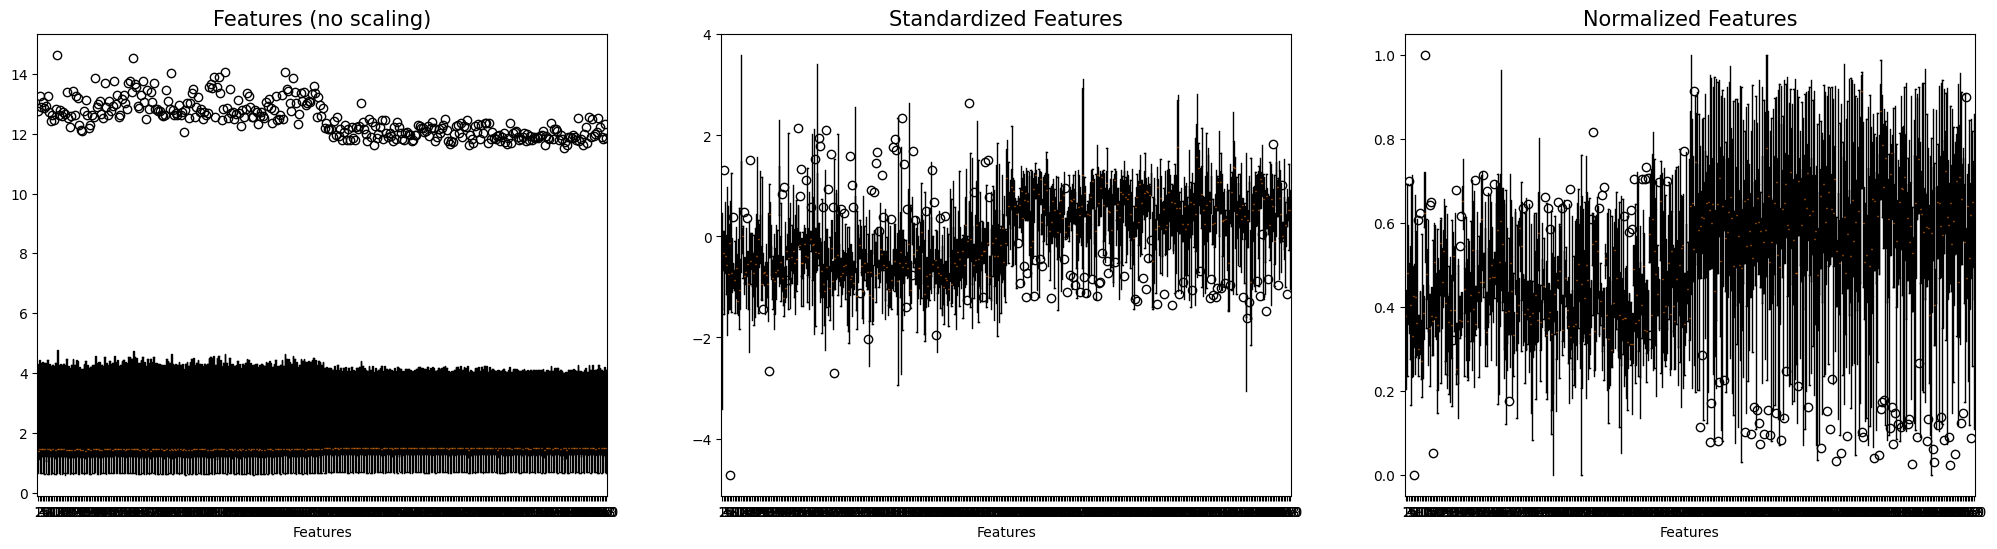

In [9]:
Start = 0  # Number of feature starts with '0'
End = 3

plt.figure(figsize=(25, 6))
plt.subplot(1, 3, 1)
plt.boxplot(FeatureSelected.iloc[:, Start : End + 1].T)
plt.title("Features (no scaling)", fontsize=15)
plt.xlabel("Features")

plt.subplot(1, 3, 2)
plt.boxplot(FeatureSelected_std.iloc[:, Start : End + 1].T)
plt.title("Standardized Features", fontsize=15)
plt.xlabel("Features")

plt.subplot(1, 3, 3)
plt.boxplot(FeatureSelected_norm.iloc[:, Start : End + 1].T)
plt.title("Normalized Features", fontsize=15)
plt.xlabel("Features")

plt.show()

## PCA Implementation

In [10]:
# Extract Principal Components (PC)
dim = 2  # Dimension to reduce
pca = PCA(n_components=dim)
PC = pca.fit_transform(FeatureSelected_std)
pd.DataFrame(PC)

,0,1
0,-3.613733,-0.158946
1,-6.349672,0.759403
2,-4.791964,0.717095
3,-4.703625,-0.695557
4,-3.841234,-1.970580
...,...,...
355,4.199619,0.496003
356,4.709764,-0.750993
357,5.058226,-0.390203
358,2.097266,-0.350900


## Visualization of PCA Result (2-D)

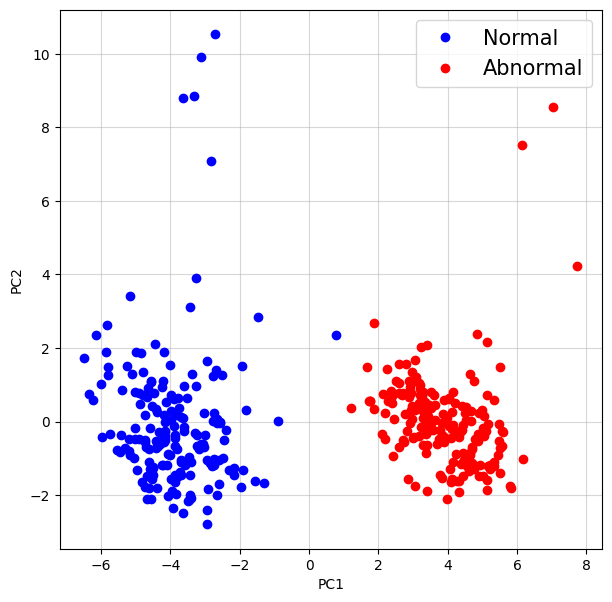

In [11]:
NoOfData = int(FeatureData.shape[1] / 2)

plt.figure(figsize=(7, 7))
plt.plot(
    PC[:NoOfData, 0],
    PC[:NoOfData, 1],
    color="b",
    linestyle="",
    marker="o",
    label="Normal",
)
plt.plot(
    PC[NoOfData:, 0],
    PC[NoOfData:, 1],
    color="r",
    linestyle="",
    marker="o",
    label="Abnormal",
)
plt.legend(fontsize=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.5)
plt.show()

# Task

- Visualize the bottom 30 features with the largest p-values in 2-D space through PCA.
    - Tip: Copy & paste above codes and modify just ONE VARIABLE (number).
    - Don't need to import packages again.

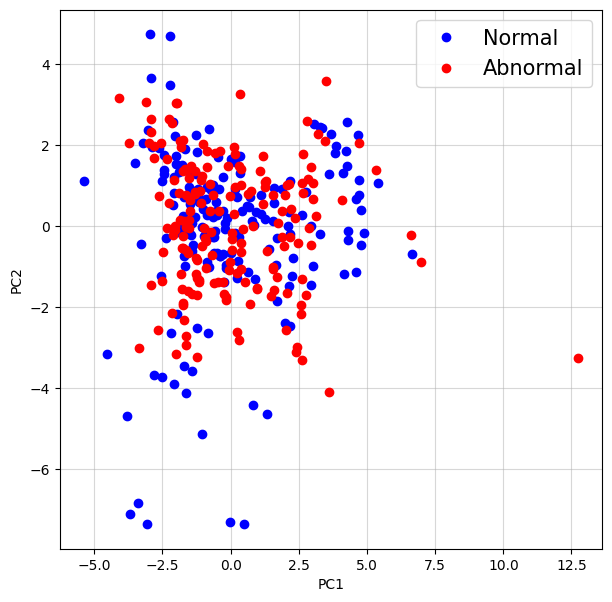

In [12]:
# Select Target Features for PCA
StartRank = 240  # Start selecting features from the end of the rank list (The only variable changed)
Num = 30

SelectedFeatues = np.zeros((Num, FeatureData.shape[1]))

s = 0
for i in range(StartRank, StartRank + Num):
    index = int(P_value_Rank.iloc[i - 1, 0])
    SelectedFeatues[s, :] = FeatureData.iloc[index, :].values
    s += 1

FeatureSelected = pd.DataFrame(SelectedFeatues).T
FeatureSelected

# Data Standardization (No Normalization)
FeatureSelected_std = StandardScaler().fit_transform(FeatureSelected)
FeatureSelected_std = pd.DataFrame(FeatureSelected_std)
FeatureSelected_std

# PCA Implementation
dim = 2  # Dimension to reduce
pca = PCA(n_components=dim)
PC = pca.fit_transform(FeatureSelected_std)
pd.DataFrame(PC)

# Visualization of PCA Result
NoOfData = int(FeatureData.shape[1] / 2)

plt.figure(figsize=(7, 7))
plt.plot(
    PC[:NoOfData, 0],
    PC[:NoOfData, 1],
    color="b",
    linestyle="",
    marker="o",
    label="Normal",
)
plt.plot(
    PC[NoOfData:, 0],
    PC[NoOfData:, 1],
    color="r",
    linestyle="",
    marker="o",
    label="Abnormal",
)
plt.legend(fontsize=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.5)
plt.show()